In [1]:
# ==========================================
# الخلية 1: تثبيت المكتبات اللازمة والاستيراد
# ==========================================
!pip install -q transformers datasets accelerate peft scikit-learn pandas seaborn matplotlib torch

import os, re, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("✅ تم تثبيت واستيراد جميع المكتبات بنجاح.")

✅ تم تثبيت واستيراد جميع المكتبات بنجاح.


In [2]:
# ==========================================
# الخلية 2: توليد التسميات (Rule-Based Labeling)
# ==========================================
def generate_repo_labels(df):
    HIERARCHY = ['AI', 'Data Science', 'Mobile', 'DevOps', 'Web']
    FULL_NAMES = {
        'AI': 'AI / Machine Learning', 'Data Science': 'Data Science',
        'Mobile': 'Mobile Applications', 'DevOps': 'DevOps', 'Web': 'Web Development'
    }
    KEYWORDS = {
        'AI': ['machine-learning', 'deep-learning', 'neural-network', 'tensorflow',
               'pytorch', 'llm', 'transformer', 'artificial-intelligence', 'nlp',
               'computer-vision', 'keras', 'scikit-learn'],
        'Data Science': ['data-science', 'pandas', 'numpy', 'data-analysis', 'visualization',
                         'matplotlib', 'jupyter', 'data-mining', 'big-data', 'sql'],
        'Mobile': ['android', 'ios', 'mobile', 'flutter', 'react-native', 'swift',
                   'kotlin', 'xamarin', 'mobile-app'],
        'DevOps': ['docker', 'kubernetes', 'ci-cd', 'devops', 'aws', 'azure', 'gcp',
                   'terraform', 'ansible', 'jenkins', 'cloud', 'infrastructure'],
        'Web': ['react', 'frontend', 'backend', 'web', 'javascript', 'vue', 'angular',
                'nodejs', 'express', 'django', 'flask', 'html', 'css', 'rest-api', 'graphql']
    }

    def classify_row(row):
        topics = row.get('topics_list', [])
        if isinstance(topics, str):
            try: topics = eval(topics)
            except: topics = [t.strip() for t in topics.replace('|', ',').split(',') if t.strip()]

        topics_lower = [t.lower() for t in topics]
        matched = {cat: sum(1 for kw in kws if kw.lower() in topics_lower) for cat, kws in KEYWORDS.items() if any(kw.lower() in topics_lower for kw in kws)}
        if not matched: return None, 0.0, "No match"

        for cat in HIERARCHY:
            if cat in matched:
                conf = min(0.95, (matched[cat] / len(KEYWORDS[cat])) * 2 + 0.5)
                return FULL_NAMES[cat], round(conf, 2), f"Matched {matched[cat]} keywords for {FULL_NAMES[cat]}"
        return None, 0.0, "Fallback"

    results = df.apply(classify_row, axis=1)
    df['label'] = [r[0] for r in results]
    df['confidence'] = [r[1] for r in results]
    df['reason'] = [r[2] for r in results]
    return df[['name', 'description', 'readme', 'topics_list', 'label', 'confidence', 'reason']]

# 🚀 التنفيذ:
df_raw = pd.read_csv('/content/cleaned_data.csv')
df_labeled = generate_repo_labels(df_raw)
df_labeled.dropna(subset=['label'], inplace=True)
print(f"✅ تم توليد التسميات. إجمالي العينات الصالحة: {len(df_labeled)}")
print(df_labeled['label'].value_counts())

✅ تم توليد التسميات. إجمالي العينات الصالحة: 465
label
AI / Machine Learning    245
DevOps                   114
Mobile Applications       52
Web Development           34
Data Science              20
Name: count, dtype: int64


/tmp/ipykernel_19981/58294827.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled.dropna(subset=['label'], inplace=True)


In [3]:
# ==========================================
# الخلية 3: دمج الفئات + التقسيم الطبقي + حساب الأوزان
# ==========================================
def merge_and_prepare_data(df_labeled):
    df_merged = df_labeled.copy()
    df_merged['label'] = df_merged['label'].replace({'Data Science': 'AI / Machine Learning'})

    # 4 فئات كما في نسخة الـ LoRA
    label2id = {
        'AI / Machine Learning': 0, 'DevOps': 1,
        'Mobile Applications': 2, 'Web Development': 3
    }
    id2label = {v: k for k, v in label2id.items()}

    class_weights = compute_class_weight('balanced', classes=np.unique(df_merged['label']), y=df_merged['label'])
    class_weights = dict(enumerate(class_weights))

    df_merged['label_id'] = df_merged['label'].map(label2id)

    train_df, temp_df = train_test_split(df_merged, test_size=0.30, stratify=df_merged['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

    print("📊 توزيع الفئات بعد الدمج:")
    print(df_merged['label'].value_counts())
    print(f"\n⚖️  الأوزان: {class_weights}")
    print(f"📈 التقسيم: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")
    return train_df, val_df, test_df, label2id, id2label, class_weights

# 🚀 التنفيذ:
train_df, val_df, test_df, label2id, id2label, class_weights = merge_and_prepare_data(df_labeled)

📊 توزيع الفئات بعد الدمج:
label
AI / Machine Learning    265
DevOps                   114
Mobile Applications       52
Web Development           34
Name: count, dtype: int64

⚖️  الأوزان: {0: np.float64(0.4386792452830189), 1: np.float64(1.019736842105263), 2: np.float64(2.235576923076923), 3: np.float64(3.4191176470588234)}
📈 التقسيم: Train=325 | Val=70 | Test=70


In [4]:
# ==========================================
# الخلية 4: تنظيف النصوص + Tokenization + Dataset Preparation
# ✅ تم إصلاح تعارض return_tensors='pt' مع مكتبة datasets
# ==========================================
def prepare_datasets(train_df, val_df, test_df, tokenizer_name="distilbert-base-uncased", max_length=512):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    def clean_text(t):
        if not isinstance(t, str): return ""
        t = re.sub(r'http\S+|www\S+', '', t)
        t = re.sub(r'!\[.*?\]\(.*?\)', '', t)
        t = re.sub(r'<[^>]+>', ' ', t)
        t = re.sub(r'```[\s\S]*?```', ' ', t)
        t = re.sub(r'[^\w\s.,!?;:\-\']', ' ', t)
        return re.sub(r'\s+', ' ', t).strip()

    def preprocess(df):
        df = df.copy()
        df['clean_text'] = df['description'].fillna('') + " [SEP] " + df['readme'].fillna('')
        df['clean_text'] = df['clean_text'].apply(clean_text)
        return df[['clean_text', 'label_id']]

    def create_ds(df):
        ds = Dataset.from_pandas(preprocess(df))
        # ✅ إزالة return_tensors='pt' لتجنب TypeError في datasets الحديثة
        return ds.map(
            lambda ex: tokenizer(ex['clean_text'], truncation=True, padding='max_length', max_length=max_length),
            batched=True, remove_columns=['clean_text']
        ).rename_column('label_id', 'labels')

    return create_ds(train_df), create_ds(val_df), create_ds(test_df), tokenizer

# 🚀 التنفيذ:
train_ds, val_ds, test_ds, tokenizer = prepare_datasets(train_df, val_df, test_df)
print("✅ تم تجهيز الـ Datasets بنجاح.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/325 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

✅ تم تجهيز الـ Datasets بنجاح.


In [5]:
# ==========================================
# 🛠️ خلية إصلاح تعارض torchao و peft
# ==========================================
!pip install -q --upgrade "torchao>=0.16.0" "peft>=0.13.0"

# إعادة تحميل المكتبات في الذاكرة لتفعيل التحديث فوراً
import importlib
import torchao, peft
importlib.reload(torchao)
importlib.reload(peft)

print("✅ تم تحديث torchao و peft بنجاح. يمكنك الآن تشغيل خلية الـ LoRA.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.8 MB/s eta 0:00:00


✅ تم تحديث torchao و peft بنجاح. يمكنك الآن تشغيل خلية الـ LoRA.


In [6]:
# ==========================================
# الخلية 5: تحميل النموذج + تطبيق LoRA (Low-Rank Adaptation)
# ==========================================
def setup_lora_model(label2id, id2label, class_weights):
    from peft import get_peft_model, LoraConfig, TaskType

    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16, lora_alpha=32, lora_dropout=0.1,
        target_modules=["q_lin", "k_lin", "v_lin", "out_lin", "fc1", "fc2"],
        bias="none"
    )

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    class_weights_tensor = torch.tensor([class_weights[i] for i in range(len(class_weights))], dtype=torch.float32)
    print("✅ تم تطبيق LoRA بنجاح.")
    return model, class_weights_tensor

# 🚀 التنفيذ:
model, class_weights_tensor = setup_lora_model(label2id, id2label, class_weights)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,183,492 || all params: 68,140,040 || trainable%: 1.7369
✅ تم تطبيق LoRA بنجاح.


In [9]:
# ==========================================
# الخلية 6 (مصححة نهائيًا): Custom Trainer + TrainingArguments
# ✅ تم إصلاح خطأ NameError: outputs is not defined
# ==========================================
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")

        # ✅ التصحيح: حفظ مخرجات النموذج كاملة أولاً
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        # الآن المتغير outputs معرف ولن يظهر الخطأ
        return (loss, outputs) if return_outputs else loss

def setup_training(model, train_dataset, val_dataset, class_weights_tensor):
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"f1_macro": f1_score(labels, preds, average='macro', zero_division=0),
                "accuracy": accuracy_score(labels, preds)}

    training_args = TrainingArguments(
        output_dir="./distilbert_lora_github", eval_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-5, per_device_train_batch_size=8, per_device_eval_batch_size=16,
        num_train_epochs=15, weight_decay=0.05, max_grad_norm=1.0,
        load_best_model_at_end=True, metric_for_best_model="f1_macro",
        greater_is_better=True, fp16=True, logging_steps=10,
        report_to="none", warmup_steps=50, save_total_limit=2
    )

    trainer = WeightedTrainer(
        class_weights=class_weights_tensor, model=model, args=training_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
    )
    print("✅ تم إعداد Trainer بنجاح.")
    return trainer

# 🚀 التنفيذ:
trainer = setup_training(model, train_ds, val_ds, class_weights_tensor)

✅ تم إعداد Trainer بنجاح.


🚀 بدء التدريب مع LoRA و Weighted Loss...



Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,1.350204,1.374808,0.180556,0.557143
2,1.405418,1.365667,0.278161,0.557143
3,1.359788,1.357423,0.274457,0.614286
4,1.317802,1.344650,0.304487,0.571429
5,1.333031,1.327891,0.364935,0.585714
6,1.288869,1.300482,0.445187,0.614286
7,1.282774,1.266150,0.432468,0.585714
8,1.178183,1.214640,0.516624,0.685714
9,1.157403,1.162219,0.523768,0.700000
10,1.070577,1.104878,0.547304,0.728571



 TRAINING SUMMARY
Steps: 615 | Loss: 1.1983

📊 EVALUATION ON TEST SET



📋 CLASSIFICATION REPORT:
                       precision    recall  f1-score   support

AI / Machine Learning       0.88      0.72      0.79        40
               DevOps       0.53      0.59      0.56        17
  Mobile Applications       0.47      1.00      0.64         8
      Web Development       1.00      0.20      0.33         5

             accuracy                           0.69        70
            macro avg       0.72      0.63      0.58        70
         weighted avg       0.76      0.69      0.69        70


🎯 FINAL MACRO F1: 0.5809


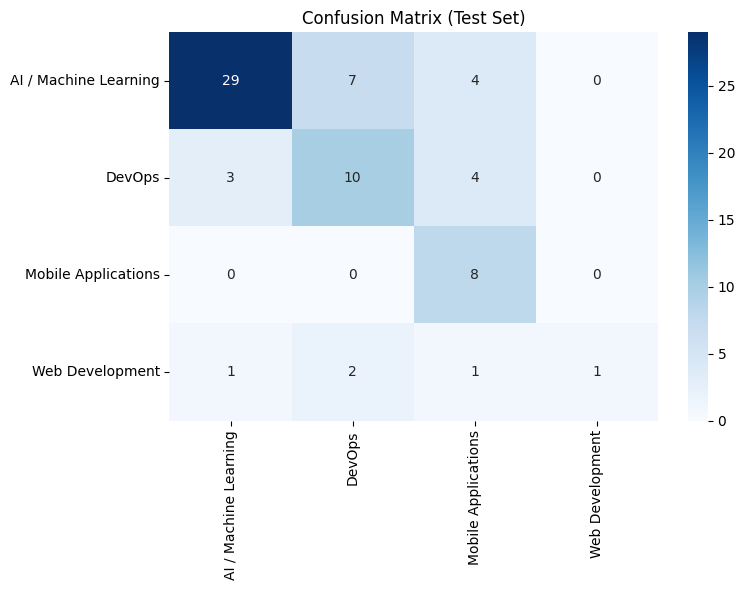

💾 تم حفظ النموذج النهائي في: ./best_lora_distilbert_model


In [10]:
# ==========================================
# الخلية 7: التشغيل النهائي + التقييم + الحفظ
# ==========================================
def train_and_evaluate_final(trainer, test_dataset, id2label):
    print("🚀 بدء التدريب مع LoRA و Weighted Loss...\n")
    train_result = trainer.train()

    print("\n" + "="*60)
    print(" TRAINING SUMMARY")
    print("="*60)
    print(f"Steps: {train_result.global_step} | Loss: {train_result.training_loss:.4f}")

    print("\n📊 EVALUATION ON TEST SET")
    print("="*60)

    preds = trainer.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids

    target_names = [id2label[i] for i in range(len(id2label))]
    print("\n📋 CLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    final_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n🎯 FINAL MACRO F1: {final_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.show()

    trainer.save_model("./best_lora_distilbert_model")
    tokenizer.save_pretrained("./best_lora_distilbert_model")
    print("💾 تم حفظ النموذج النهائي في: ./best_lora_distilbert_model")
    return final_f1

#  التنفيذ النهائي:
final_f1 = train_and_evaluate_final(trainer, test_ds, id2label)